<a href="https://colab.research.google.com/github/paarthbamb/dataScience/blob/main/PaarBambUnit6Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Unit 6 Project: Generalized Linear Models**

**Part 0: Notebook Setup**

In [ ]:
import pandas as pd
import numpy as np
import pymc as pm
import arviz as az
import seaborn as sns
import matplotlib.pyplot as plt
!pip install bambi
import bambi as bmb

# Load the dataset
nfl_data = pd.read_csv("https://raw.githubusercontent.com/paarthbamb/nflData/refs/heads/main/nfl_games_weather_sample.csv")

nfl_data.head()

**Part I: Introduction**

For my Unit 6 project, I will be creating a linear model with multiple predictors
to predict the total points scored in NFL games from three weather-related factors:
temperature (temperature_f), wind speed (wind_mph), and humidity (humidity_pct).

I thought this topic would be interesting because weather conditions are known to
significantly impact football games, particularly outdoor games. Cold temperatures
can make the ball harder to grip and throw, high winds can affect passing and kicking
accuracy, and humidity can impact player stamina and ball handling.

> Extra Information:
Weather has long been considered a critical "home field advantage" factor in the NFL.
Teams that play in extreme climates (like Green Bay's frigid winters or Miami's heat
and humidity) are thought to have an edge when hosting opponents unfamiliar with those
conditions. Research has shown that temperature below 40°F can reduce scoring by
affecting quarterback accuracy and limiting offensive play-calling to more conservative,
run-heavy approaches. Wind speeds above 15 mph significantly impact field goal
percentages and deep passing plays, as the ball trajectory becomes unpredictable.
High humidity (above 80%) can lead to more fumbles due to slippery conditions and
affect player endurance throughout the game. Understanding how these factors interact together is important for teams' strategic planning and even sports betting
markets.



**Part II: Data**

The data I am using comes from NFL game records that include detailed weather
information for each game. The dataset contains games from the 2010-2020 seasons
and includes weather measurements taken at kickoff. Let's upload the data by reading
the csv file.

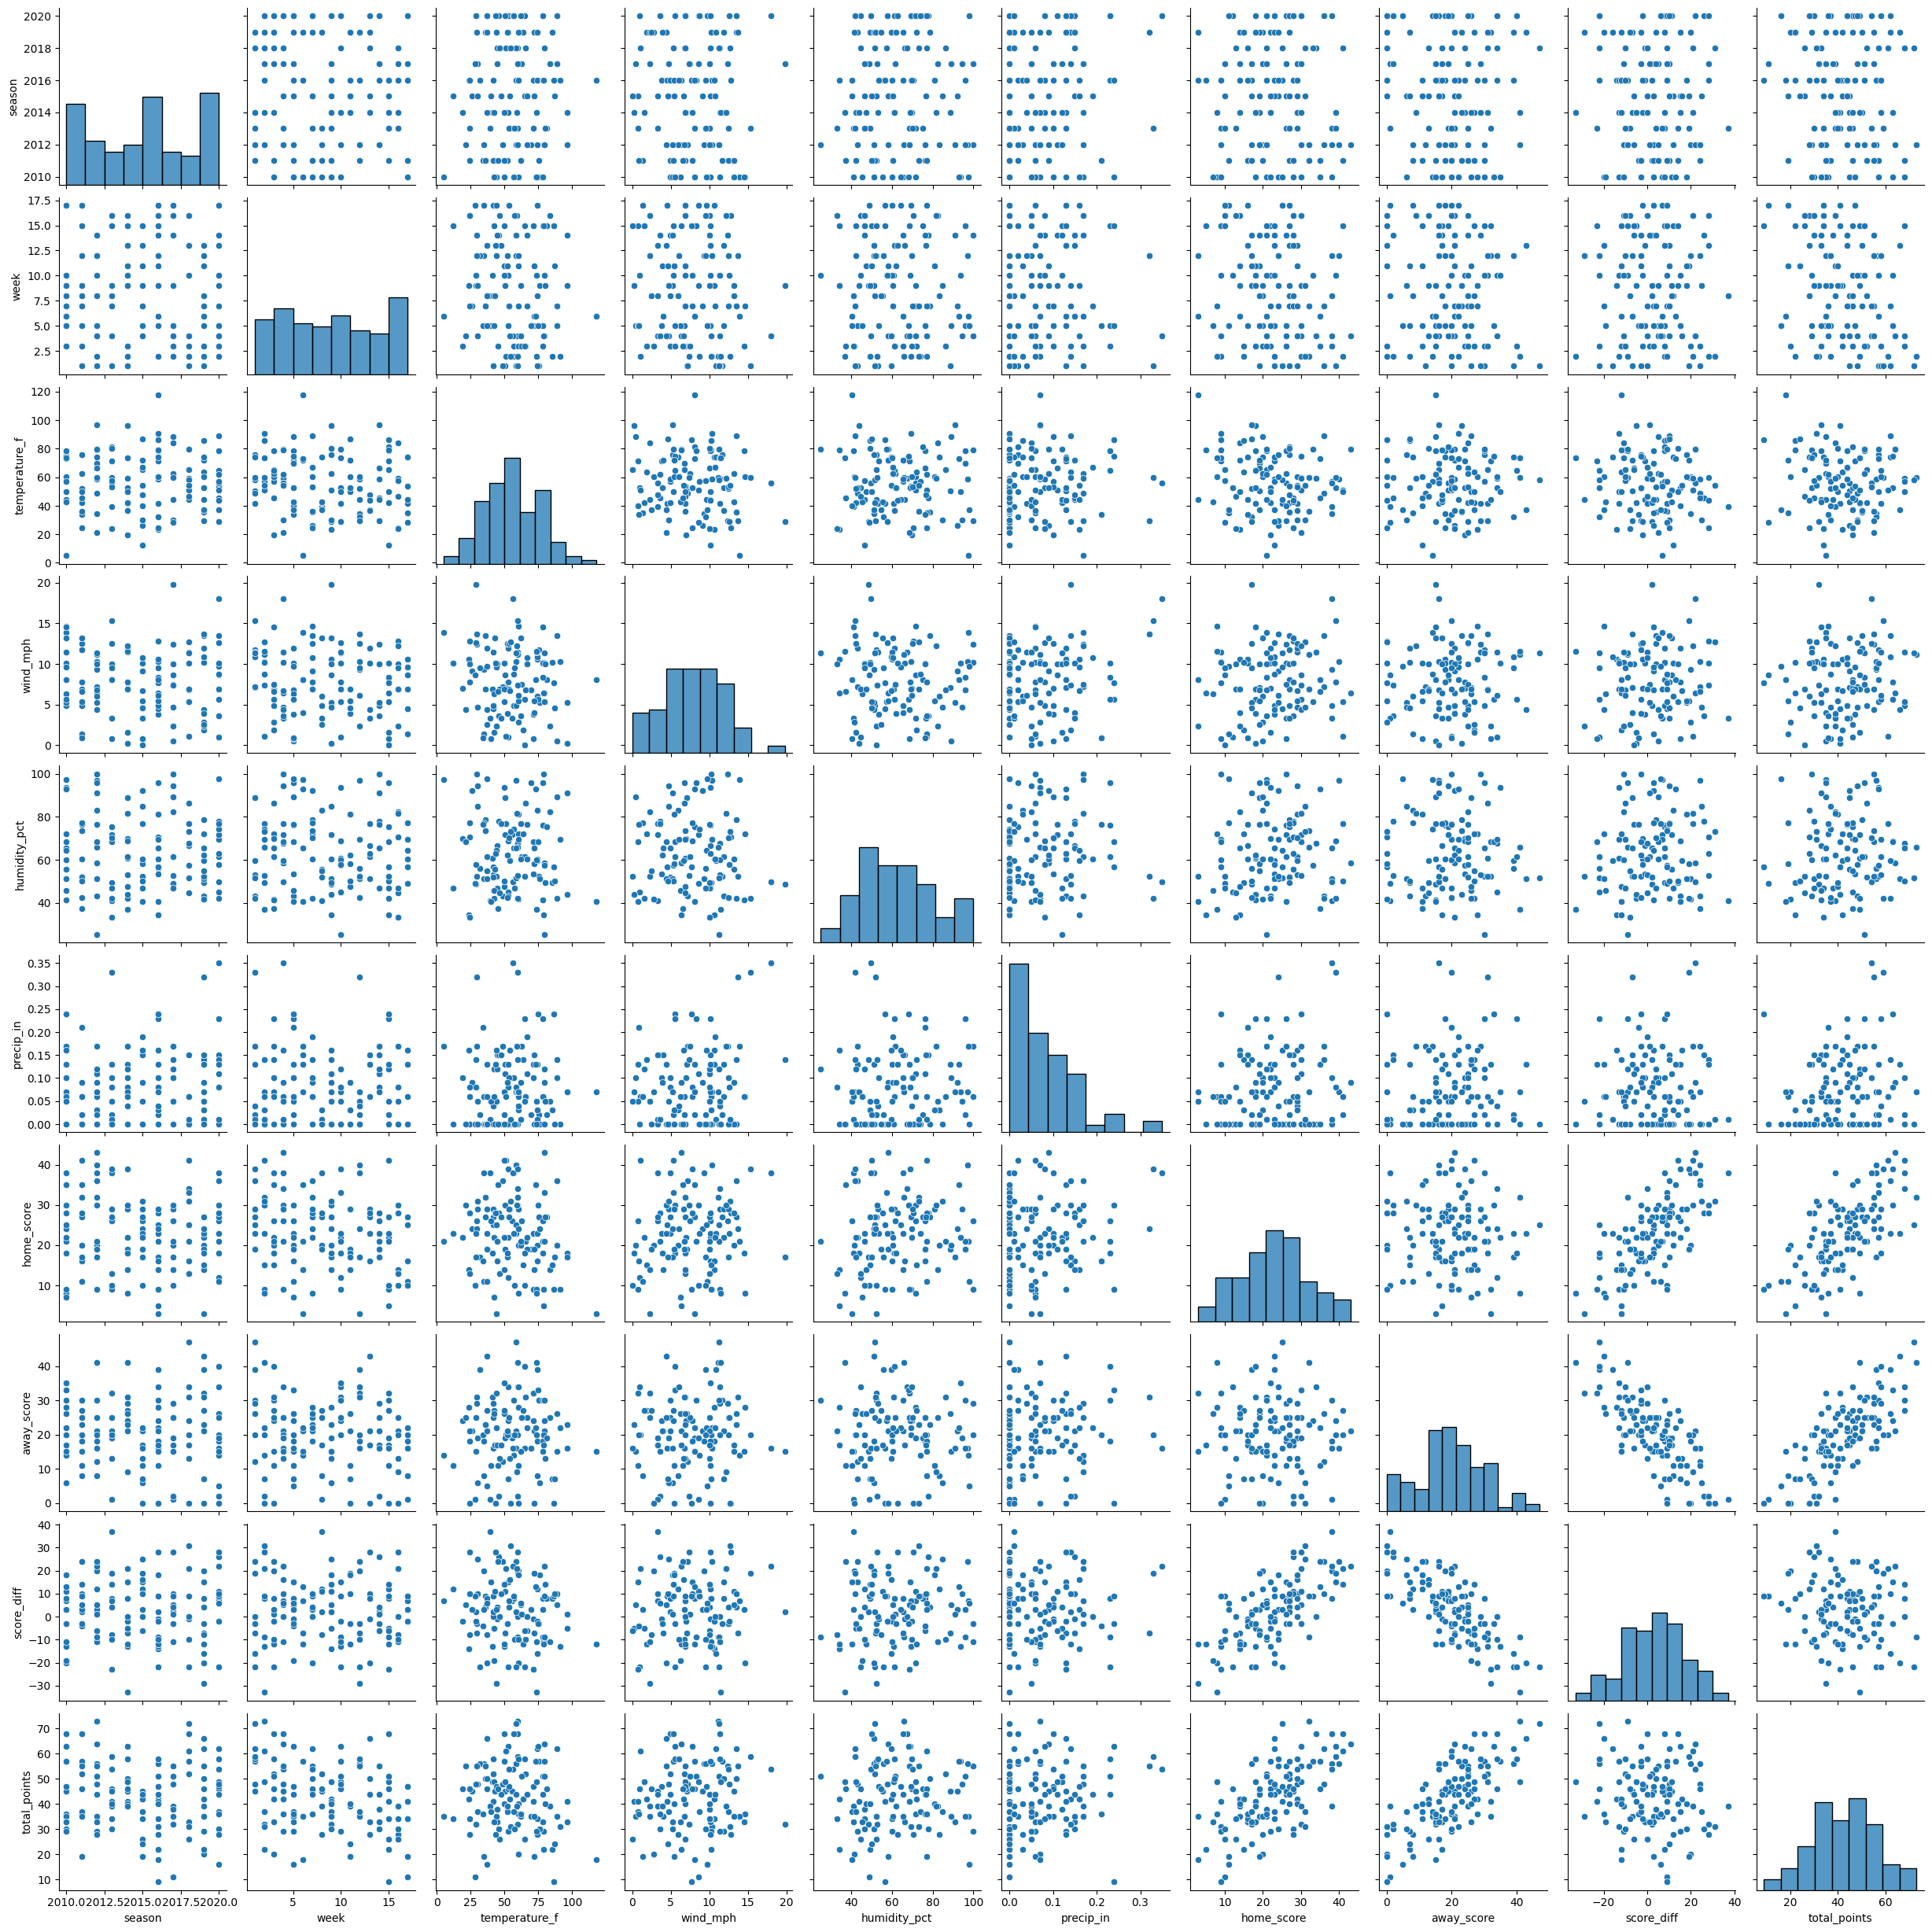

In [5]:
sns.pairplot(nfl_data)
plt.show()

Some of the pairwise relationships in my dataset are strong linear corelations, so I will go ahead and use this data for my models.

**Part III: Multiple Linear Models (Combinations)**

We will be using the Python library Bambi to create our multi-linear models. I will
create six different combinations of the three weather factors and use elpd_loo to
check which model performs the best at the end. The six combinations I will use are
as follows:

1. temperature_f, wind_mph, humidity_pct (no interactions)
2. temperature_f, wind_mph, humidity_pct, and interactions between all three (two at a time)
3. temperature_f, wind_mph, humidity_pct, interaction between temperature_f and wind_mph
4. temperature_f, wind_mph, humidity_pct, interaction between temperature_f and humidity_pct
5. temperature_f, wind_mph, humidity_pct, interaction between wind_mph and humidity_pct
6. temperature_f, wind_mph, humidity_pct, and interactions between all three (all three at the same time)
"""


Model 1: main effects only, no interactions

In [ ]:
# Define the model
model_1 = bmb.Model("total_points ~ temperature_f + wind_mph + humidity_pct", data=nfl_data)
# Fit the model
idata_1 = model_1.fit(idata_kwargs={'log_likelihood': True})

I can't plot this model as it's comparing three variables.

Model 2: all pairwise interactions

In [ ]:
# Define the model
model_2 = bmb.Model("total_points ~ temperature_f + wind_mph + humidity_pct + temperature_f:wind_mph + temperature_f:humidity_pct + wind_mph:humidity_pct", data=nfl_data)
# Fit the model
idata_2 = model_2.fit(idata_kwargs={'log_likelihood': True})

Similar to Model 1, I can't plot this model as it's comparing three variables.

Model 3: temperature x wind

In [ ]:
# Define the model
model_3 = bmb.Model("total_points ~ temperature_f + wind_mph + humidity_pct + temperature_f:wind_mph", data=nfl_data)
# Fit the model
idata_3 = model_3.fit(idata_kwargs={'log_likelihood': True})

(<Figure size 1100x1300 with 1 Axes>,
 array([<Axes: xlabel='temperature_f', ylabel='total_points'>],
       dtype=object))

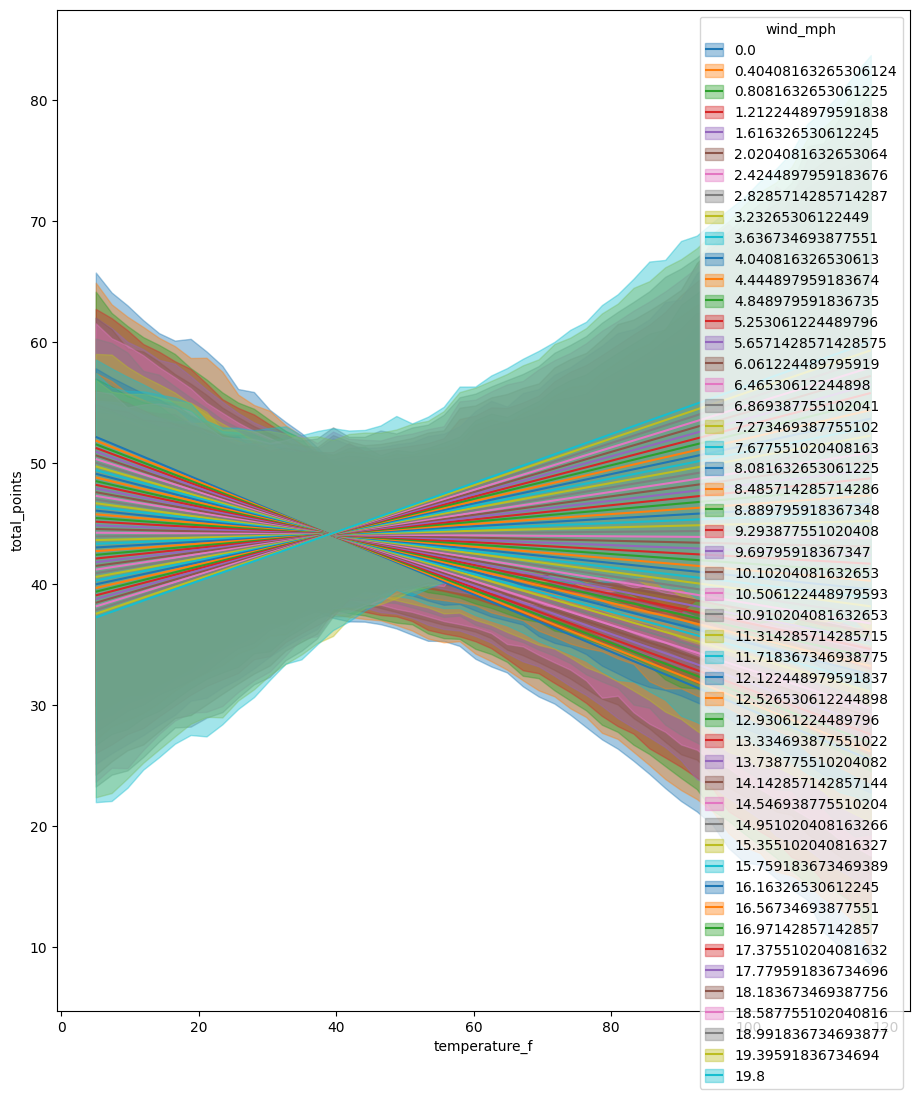

In [9]:
bmb.interpret.plot_predictions(model_3,
                               idata_3,
                               ["temperature_f", "wind_mph"],
                               fig_kwargs={"figsize": (11, 13)})#,
                               #legend=False)

Model 4: temp x humidity

In [ ]:
# Define the model
model_4 = bmb.Model("total_points ~ temperature_f + wind_mph + humidity_pct + temperature_f:humidity_pct", data=nfl_data)
# Fit the model
idata_4 = model_4.fit(idata_kwargs={'log_likelihood': True})

(<Figure size 1100x1300 with 1 Axes>,
 array([<Axes: xlabel='temperature_f', ylabel='total_points'>],
       dtype=object))

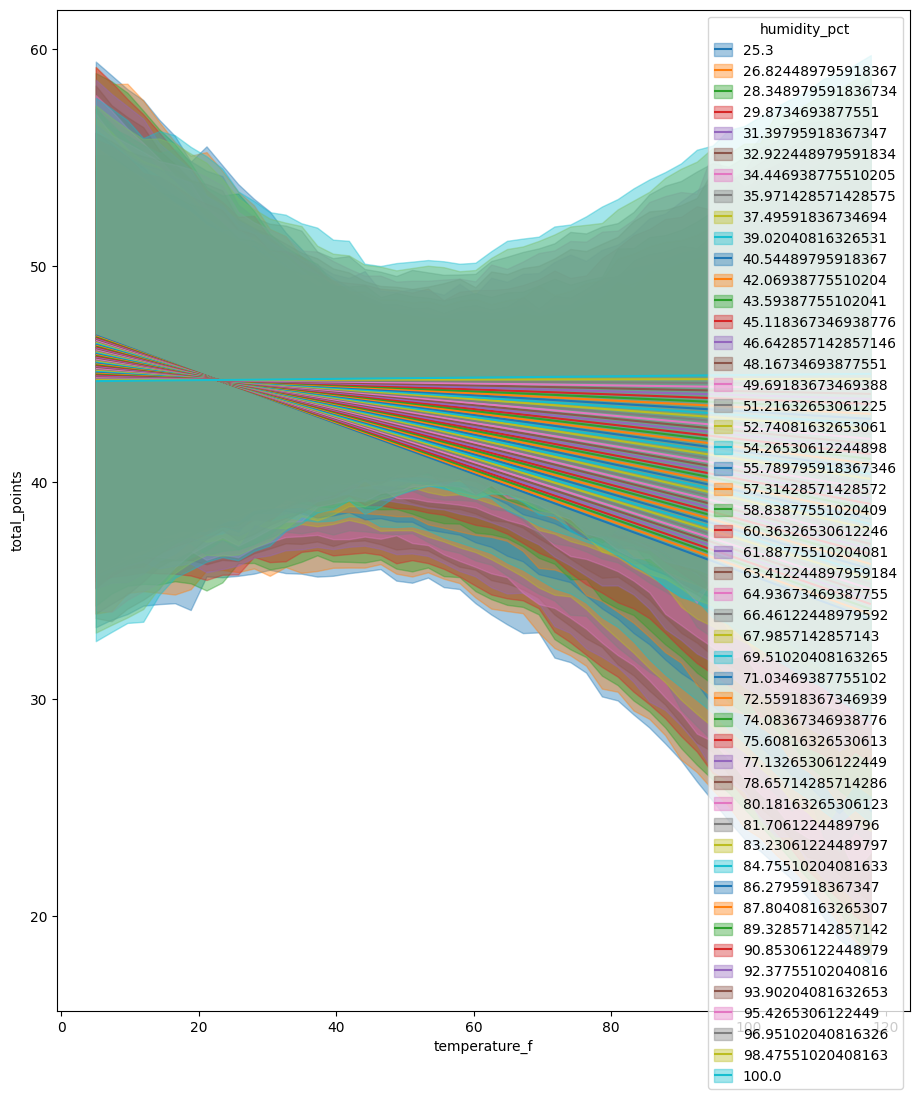

In [11]:
bmb.interpret.plot_predictions(model_4,
                               idata_4,
                               ["temperature_f", "humidity_pct"],
                               fig_kwargs={"figsize": (11, 13)})#,
                               #legend=False)

Model 5: wind x humidity

In [ ]:
# Define the model
model_5 = bmb.Model("total_points ~ temperature_f + wind_mph + humidity_pct + wind_mph:humidity_pct", data=nfl_data)
# Fit the model
idata_5 = model_5.fit(idata_kwargs={'log_likelihood': True})

(<Figure size 1100x1300 with 1 Axes>,
 array([<Axes: xlabel='wind_mph', ylabel='total_points'>], dtype=object))

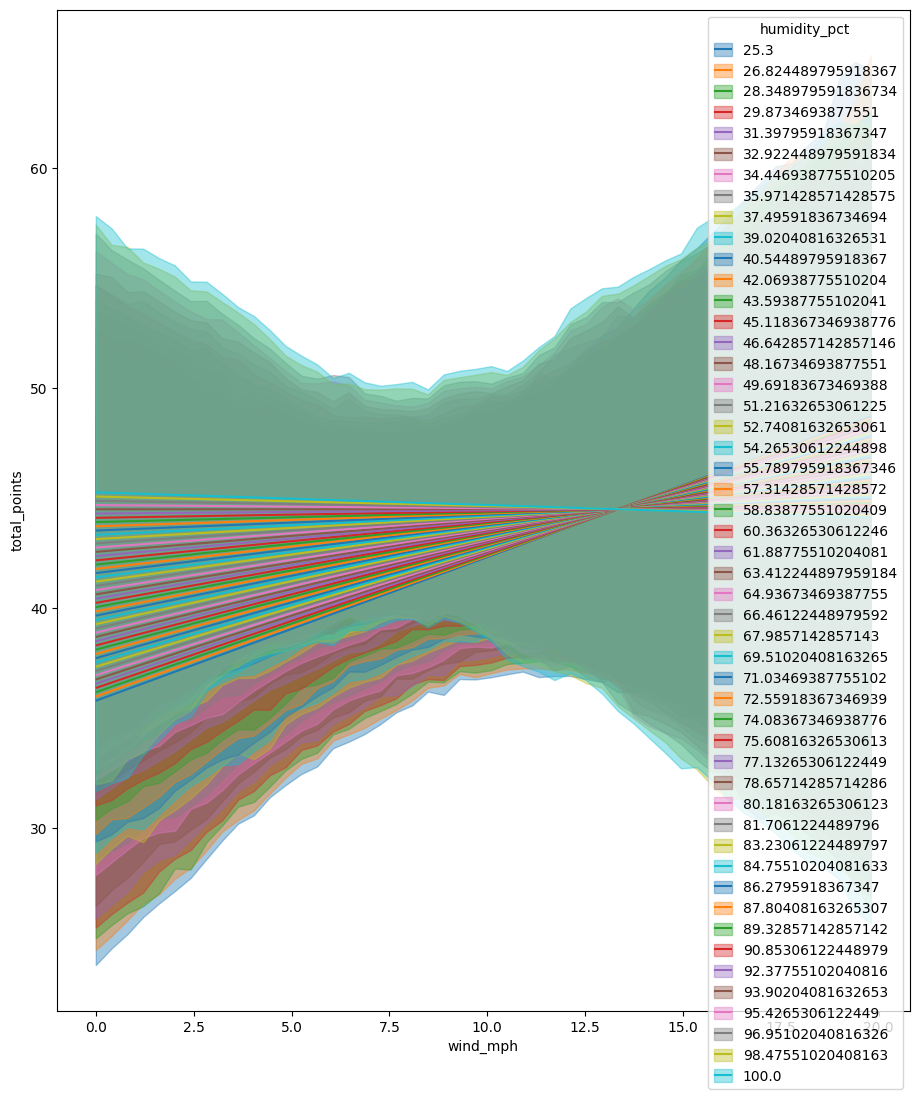

In [13]:
bmb.interpret.plot_predictions(model_5,
                               idata_5,
                               ["wind_mph", "humidity_pct"],
                               fig_kwargs={"figsize": (11, 13)})#,
                               #legend=False)

Model 6: three-way interaction

In [ ]:
# Define the model
model_6 = bmb.Model("total_points ~ temperature_f + wind_mph + humidity_pct + temperature_f:wind_mph:humidity_pct", data=nfl_data)
# Fit the model
idata_6 = model_6.fit(idata_kwargs={'log_likelihood': True})

Similar to Models 1 and 2, I can't plot this model as it's comparing three variables.

**Part III: Comparison**

Now that we have fitted all six models, we can compare their predictive performance using Leave-One-Out Cross-Validation (LOO-CV). The elpd_loo (Expected Log Predictive Density) metric tells us how well each model predicts out-of-sample data, with higher values indicating better predictive performance.

In [15]:
cmp = az.compare({"1":idata_1,"2":idata_2, "3":idata_3, "4":idata_4, "5":idata_5, "6":idata_6})

<Axes: title={'center': 'Model comparison\nhigher is better'}, xlabel='elpd_loo (log)', ylabel='ranked models'>

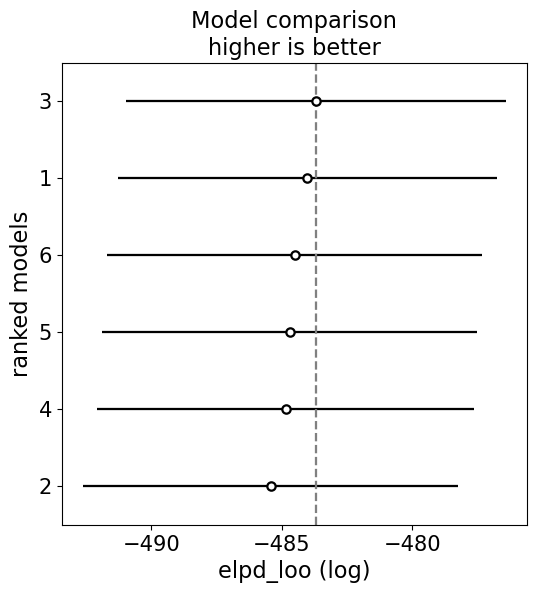

In [16]:
az.plot_compare(cmp)

Overall, all six models perform about the same, since their uncertainty intervals overlap a lot. This means there isn’t a clear “best” model, and adding interaction terms doesn’t significantly improve how well the models predict NFL scoring.

Model 3, which includes the interaction between temperature and wind, performs slightly better than the others, which suggests that cold and windy conditions together may make scoring more difficult than either factor on its own, which makes intuitive sense. However, the simpler model with only main effects performs nearly as well, showing that most of weather’s impact on scoring can be explained by temperature, wind, and humidity acting independently.

The most complex model, which includes all pairwise interactions, performs worse. This could be due to overfitting and capturing noise rather than meaningful patterns.

This project was fun and I definitely learned a lot!